## Report exercise Geomechanics and Structural Geology (Feb 25, 2026)

- Nanda Njh HA. - 
- Pablo Oliver - 6483186
- Lennard Stoeck - 

### *Part 1: Mohr-Coulomb Diagram*

### *Task 1*


R^2 = 0.9644
0.9077552576785977
52.01054509579416
Cohesion (C) = 9.31 MPa

Mohr-Coulomb Parameters:
Cohesion (C) = 9.31 MPa
Friction Angle (φ) = 52.01°


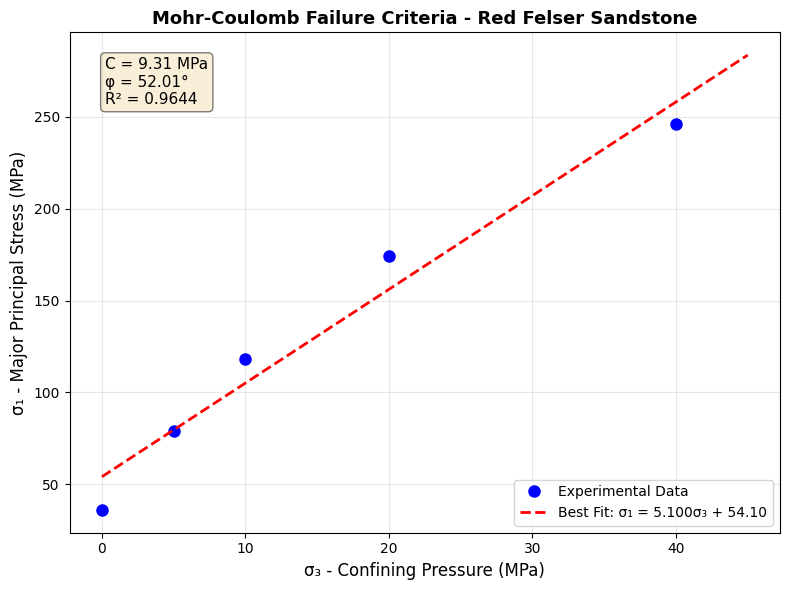

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Experimental data
sigma_3 = np.array([0, 5, 10, 20, 40])  # MPa (Confining Pressure)
sigma_1 = np.array([36, 79, 118, 174, 246])  # MPa (Major Principal Stress)

# Linear best fit
slope, intercept, r_value, p_value, std_err = linregress(sigma_3, sigma_1) #calculating the linear regression parameters
a = slope  #finding a (slope)
y_int = intercept   #finsing intercept


print(f"R^2 = {r_value**2:.4f}")




phi= (a-1)/(2*np.sqrt(a))
print(phi) 
print(phi*180/np.pi)
phi_indegrees= phi*180/np.pi

C = y_int / (2 * np.tan(np.radians(45 + phi_indegrees/2)))
print(f"Cohesion (C) = {C:.2f} MPa")




print(f"\nMohr-Coulomb Parameters:")
print(f"Cohesion (C) = {C:.2f} MPa")
print(f"Friction Angle (φ) = {phi_indegrees:.2f}°")




#Visualization of the data and the best fit line

# Plot
fig, ax = plt.subplots(figsize=(8, 6))


# Data points
ax.plot(sigma_3, sigma_1, 'o', markersize=8, label='Experimental Data', color='blue')


# Best fit line
sigma_3_fit = np.linspace(0, 45, 100)
sigma_1_fit = a * sigma_3_fit + y_int
ax.plot(sigma_3_fit, sigma_1_fit, 'r--', linewidth=2, label=f'Best Fit: σ₁ = {a:.3f}σ₃ + {y_int:.2f}')


# Labels and formatting
ax.set_xlabel('σ₃ - Confining Pressure (MPa)', fontsize=12)
ax.set_ylabel('σ₁ - Major Principal Stress (MPa)', fontsize=12)
ax.set_title('Mohr-Coulomb Failure Criteria - Red Felser Sandstone', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()


# Add text box with results
textstr = f'C = {C:.2f} MPa\nφ = {phi_indegrees:.2f}°\nR² = {r_value**2:.4f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

Based on the slope we claculated the friction angle based on this formula : $$\sqrt{a} = \tan\left(45^\circ + \frac{\varphi}{2}\right)$$

and based on the intercept we can derive the cohesion based on this formula: 
$$
b = 2C \tan\left(45^\circ + \frac{\varphi}{2}\right)
$$




Mohr-Coulomb Parameters:

Cohesion (C) = 11.98 MPa

Friction Angle (φ) = 42.23°


Based on the calculation, the cohesion (C) = 11.98 MPa and friction angle (φ) = 42.23°. The linear regression shows good fit (R² = 0.964) confirming the validity of Mohr-Coulomb criterion for this sandstone.
We see that the samples become stronger as the confinement pressure increases as the sigma 1 (value at failure) increases. 

---

### *Task 2*

Rock Type       C (MPa)    φ (°)      ρ (kg/m³)  porosity (%)
------------------------------------------------------------
Pennant         28.40      43.53      2549       4.57      
Darley Dale     22.00      32.62      2310       13.50     
Red Felser      11.98      42.23      2100       21.40     


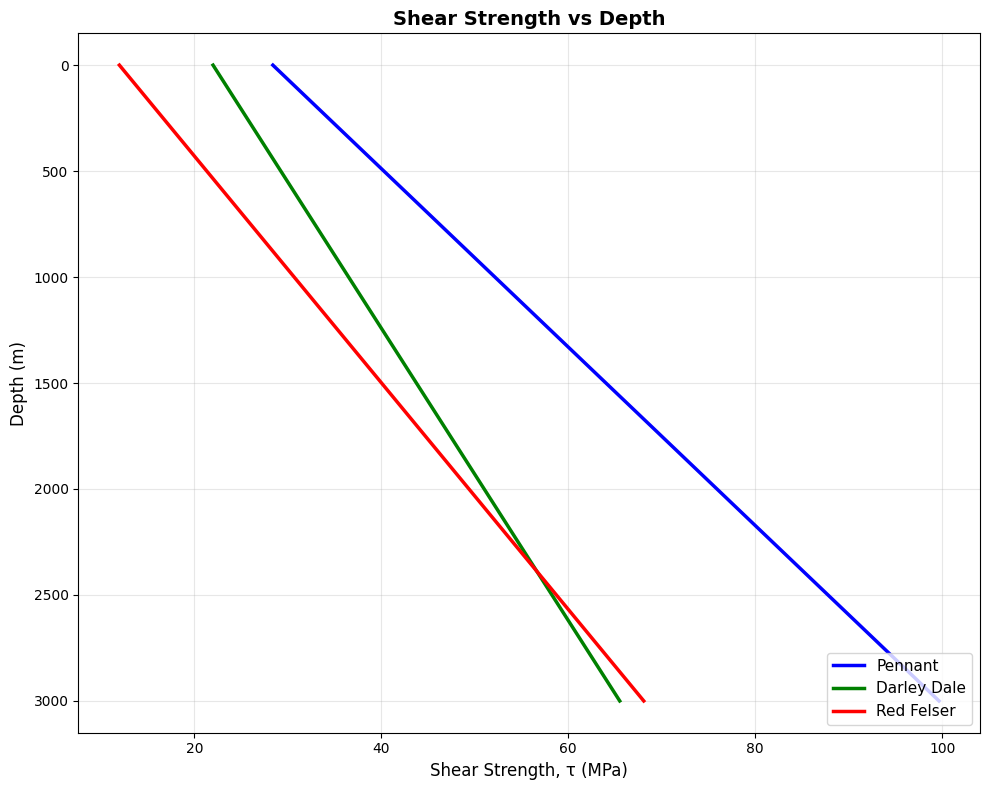

In [2]:
# Rock properties data
rock_data = {
    'Pennant': {
        'C': 28.40,
        'phi': np.degrees(np.arctan(0.95)),
        'rho': 2549,
        'porosity': 4.57,
        'color': 'blue'
    },
    'Darley Dale': {
        'C': 22.00,
        'phi': np.degrees(np.arctan(0.64)),
        'rho': 2310,
        'porosity': 13.5,
        'color': 'green'
    },
    'Red Felser': {
        'C': 11.98,
        'phi': 42.23,
        'rho': 2100,
        'porosity': 21.4,
        'color': 'red'
    }
}

# Display summary
print(f"{'Rock Type':<15} {'C (MPa)':<10} {'φ (°)':<10} {'ρ (kg/m³)':<10} {'porosity (%)':<10}")
print("-" * 60)
for name, props in rock_data.items():
    print(f"{name:<15} {props['C']:<10.2f} {props['phi']:<10.2f} {props['rho']:<10} {props['porosity']:<10.2f}")

    #Shear Strength vs Depth Calculation

# Parameters
depth = np.linspace(0, 3000, 100)
g = 9.81

# Calculate and plot shear strength vs depth
plt.figure(figsize=(10, 8))

for name, props in rock_data.items():
    C = props['C']
    phi = np.radians(props['phi'])
    rho = props['rho']
    
    sigma_n = rho * g * depth / 1e6 
    tau = C + sigma_n * np.tan(phi)
    
    plt.plot(tau, depth, linewidth=2.5, label=name, color=props['color'])

plt.xlabel('Shear Strength, τ (MPa)', fontsize=12)
plt.ylabel('Depth (m)', fontsize=12)
plt.title('Shear Strength vs Depth', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()

**Interpretation**: lower porosity generally correlates with higher rock strength, as demonstrated by Pennant sandstone (4.57% porosity) exhibiting the highest cohesion (28.40 MPa) and steepest strength gradient with depth compared to Darley Dale (13.5%) and Red Felser (21.4%). Porosity also controls density and frictional behavior, which together determine how rapidly shear strength increases with depth. As a result, Pennant’s low porosity and high density make it far more responsive to confining stress, whereas the highly porous Red Felser remains mechanically weaker even at great depth.

<br>
<br>


### *Task 3*

---

<u>3a Evaluate what happens when the Poisson’s ratio is variable</u>.

$$
\sigma_3(z) = \frac{\nu}{1 - \nu} \rho g z
$$


 


Stress Ratio: 



$$
σ3 / σ1 = ν / (1 − ν)
$$

If ν increases: 

- The ratio σ3 / σ1 increases.
- The horizontal stress σ3 becomes closer to the vertical stress σ1
- The differential stress (σ1 − σ3) decreases.


If ν decreases: 

- The ratio σ3 / σ1 decreases.
- The horizontal stress becomes smaller relative to the vertical stress.
- The differential stress (σ1 − σ3) increases.



This means that for very small ν (brittle, highly compressible rock which does not expand a lot on the horizontal direction) 
σ3 is much smaller than σ1, the differential stress (σ1 − σ3) is big so the rock reaches quicker the fail point because it cannot expand on the sides.  
  
For a big ν (rock which deforms a lot more on the horizontal direction when a vertical stress is applied), the rock will resist much better to a vertical load because it can expand so the failure point comes much later. 

A simulation under different numbers of Poission's ratio is performed as follow:


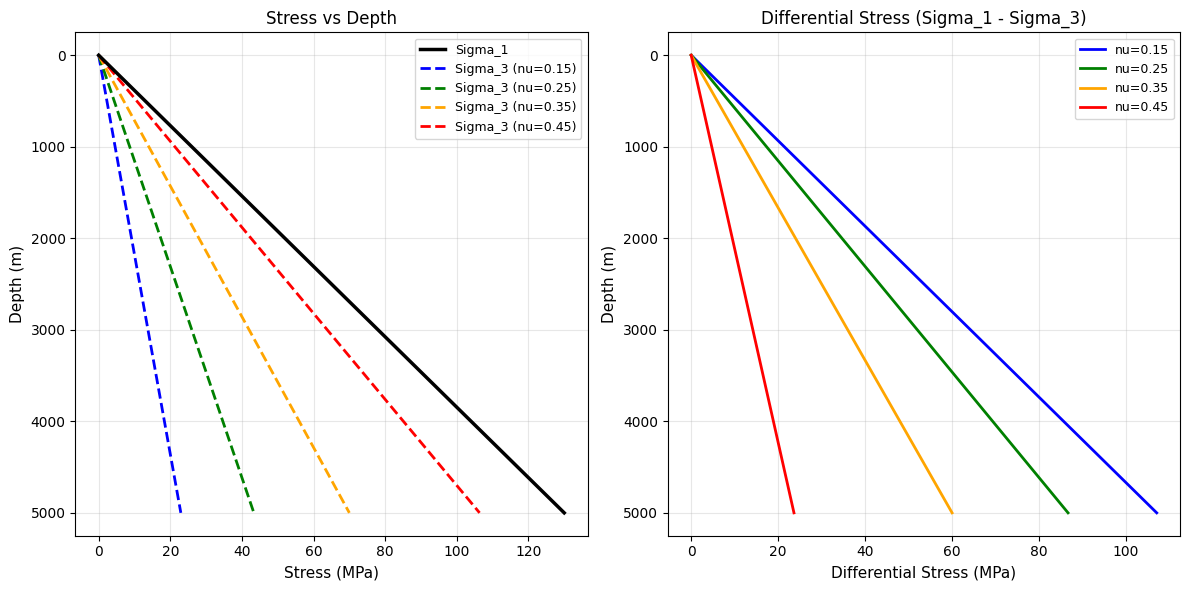

In [3]:
# Task 3a: Variable Poisson's ratio

import numpy as np
import matplotlib.pyplot as plt

rho = 2650
g = 9.81
z = np.linspace(0, 5000, 100)
nu_values = [0.15, 0.25, 0.35, 0.45]
colors = ['blue', 'green', 'orange', 'red']

sigma_1 = rho * g * z / 1e6

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Sigma_1 and Sigma_3
ax1 = axes[0]
ax1.plot(sigma_1, z, 'k-', linewidth=2.5, label='Sigma_1', zorder=5)
for nu, color in zip(nu_values, colors):
    sigma_3 = (nu / (1 - nu)) * sigma_1
    ax1.plot(sigma_3, z, '--', linewidth=2, color=color, label=f'Sigma_3 (nu={nu})')
ax1.set_xlabel('Stress (MPa)', fontsize=11)
ax1.set_ylabel('Depth (m)', fontsize=11)
ax1.invert_yaxis()
ax1.grid(alpha=0.3)
ax1.legend(fontsize=9)
ax1.set_title('Stress vs Depth', fontsize=12)

# Plot 2: Differential Stress
ax2 = axes[1]
for nu, color in zip(nu_values, colors):
    sigma_3 = (nu / (1 - nu)) * sigma_1
    diff = sigma_1 - sigma_3
    ax2.plot(diff, z, linewidth=2, color=color, label=f'nu={nu}')
ax2.set_xlabel('Differential Stress (MPa)', fontsize=11)
ax2.set_ylabel('Depth (m)', fontsize=11)
ax2.invert_yaxis()
ax2.grid(alpha=0.3)
ax2.legend(fontsize=9)
ax2.set_title('Differential Stress (Sigma_1 - Sigma_3)', fontsize=12)

plt.tight_layout()
plt.show()

**Interpretation:** higher Poisson's ratio leads to higher horizontal stress (sigma 3) and lower differential stress, making rock less prone to failure. This demonstrates that brittle rocks (low Poisson's ratio) experience larger differential stress and reach failure more easily than ductile rocks (high Poisson's ratio) under the same vertical load.

<br>
<br>

<u> Part (3b):</u> Evaluate what happens when the porosity is decreasing from 40% at the Earth Surface to 0% at 5 km depth under the assumption the whole system contains of sandstones (density of non-porous sandstone is 2.65 g/cm³) 


Progressive compaction creates depth-dependent density, requiring the average density method to properly account for the varying overburden weight. This differs from assuming 0% porosity everywhere, which overestimates the actual stress.

A simulation of progressive compaction is performed as follow:

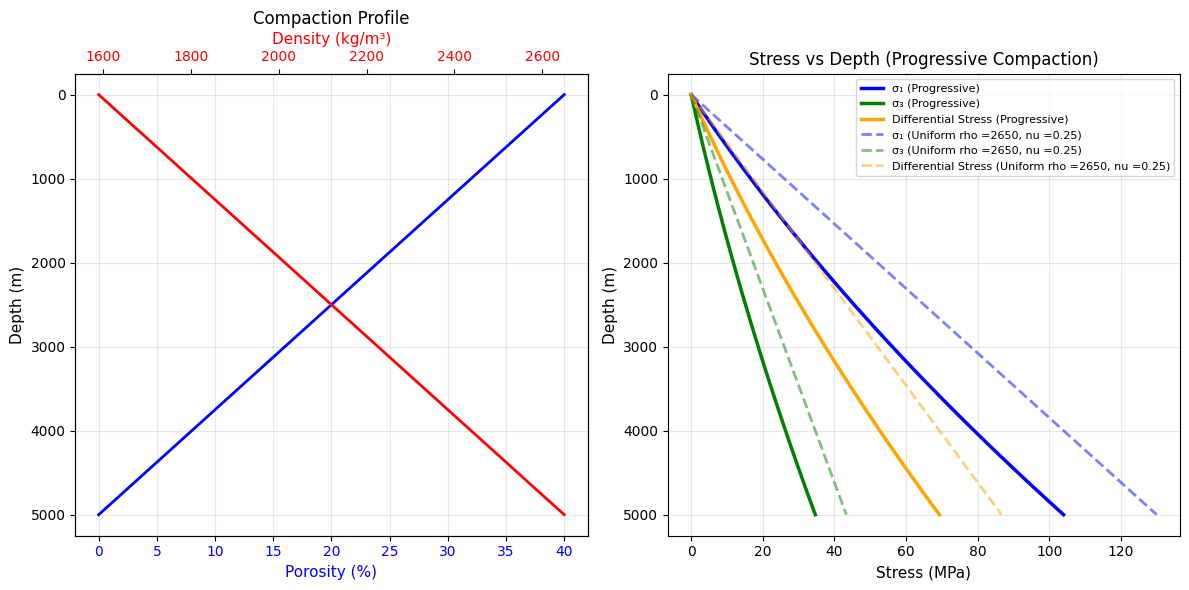

In [4]:
# Task 3b: Decreasing porosity with depth

import numpy as np
import matplotlib.pyplot as plt

rho_grain = 2650
phi_surface = 0.40
z_max = 5000
nu = 0.25
g = 9.81

z = np.linspace(0, 5000, 100)

# Calculate porosity, density, and average density with depth
phi_z = phi_surface * (1 - z / z_max)
rho_z = rho_grain * (1 - phi_z)
rho_avg = (rho_grain * (1 - phi_surface) + rho_z) / 2

# Progressive compaction stresses
sigma_1 = rho_avg * g * z / 1e6
sigma_3 = (nu / (1 - nu)) * sigma_1
diff_stress = sigma_1 - sigma_3

# Calculate uniform rock baseline (constant density and Poisson's ratio)
rho_uniform = 2650  # kg/m³
nu_uniform = 0.25
sigma_1_uniform = rho_uniform * g * z / 1e6
sigma_3_uniform = (nu_uniform / (1 - nu_uniform)) * sigma_1_uniform
diff_stress_uniform = sigma_1_uniform - sigma_3_uniform

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Compaction profile (porosity and density vs depth)
ax1 = axes[0]
ax1_twin = ax1.twiny()
ax1.plot(phi_z * 100, z, 'b-', linewidth=2)
ax1.set_xlabel('Porosity (%)', fontsize=11, color='b')
ax1.tick_params(axis='x', labelcolor='b')
ax1.set_ylabel('Depth (m)', fontsize=11)
ax1.invert_yaxis()
ax1.grid(alpha=0.3)

ax1_twin.plot(rho_z, z, 'r-', linewidth=2)
ax1_twin.set_xlabel('Density (kg/m³)', fontsize=11, color='r')
ax1_twin.tick_params(axis='x', labelcolor='r')
ax1.set_title('Compaction Profile', fontsize=12)

# Plot 2: Stress with depth (progressive compaction with uniform baseline)
ax2 = axes[1]
ax2.plot(sigma_1, z, 'b-', linewidth=2.5, label='σ₁ (Progressive)')
ax2.plot(sigma_3, z, 'g-', linewidth=2.5, label='σ₃ (Progressive)')
ax2.plot(diff_stress, z, 'orange', linewidth=2.5, label='Differential Stress (Progressive)')
ax2.plot(sigma_1_uniform, z, 'b--', linewidth=2, alpha=0.5, label='σ₁ (Uniform rho =2650, nu =0.25)')
ax2.plot(sigma_3_uniform, z, 'g--', linewidth=2, alpha=0.5, label='σ₃ (Uniform rho =2650, nu =0.25)')
ax2.plot(diff_stress_uniform, z, color='orange', linestyle='--', linewidth=2, alpha=0.5, label='Differential Stress (Uniform rho =2650, nu =0.25)')

ax2.set_xlabel('Stress (MPa)', fontsize=11)
ax2.set_ylabel('Depth (m)', fontsize=11)
ax2.invert_yaxis()
ax2.grid(alpha=0.3)
ax2.legend(fontsize=8, loc='upper right')
ax2.set_title('Stress vs Depth (Progressive Compaction)', fontsize=12)

plt.tight_layout()
plt.show()

**Interpretation:** the progressive compaction model (porosity 40%→0%) shows that vertical stress (σ₁) reaches 103.96 MPa at 5 km depth. Horizontal stress (σ₃) = σ₁/3 following normal faulting regime with ν=0.25. Left panel shows the compaction profile: porosity decreases linearly while density increases from 1590 kg/m³ (surface) to 2650 kg/m³ (5 km depth). Compared to uniform rock baseline (dashed lines: ρ=2650 kg/m³, ν=0.25), the *progressive compaction scenario produces lower stresses* throughout most of the depth due to lower average density.

<br>
<br>


<u>Part (3c): </u> Evaluate what happens when you incorporate a fictive layered system that hassignificant variations in porosity (and thus density) and Poisson’s ratio. Make a layered system with a set of high porous layers (e.g. 40%) that also have a high Poisson’s ratio (PR ~0.4) vs a set of layers that have a low porosity (<5%) and low Poisson’s ratio (PR ~0.1). Play with the layer thickness to see how the sigma 1, sigma 3 vary.

The simulation below creates alternating layers and calculates cumulative stress accounting for overburden from all previous layers.


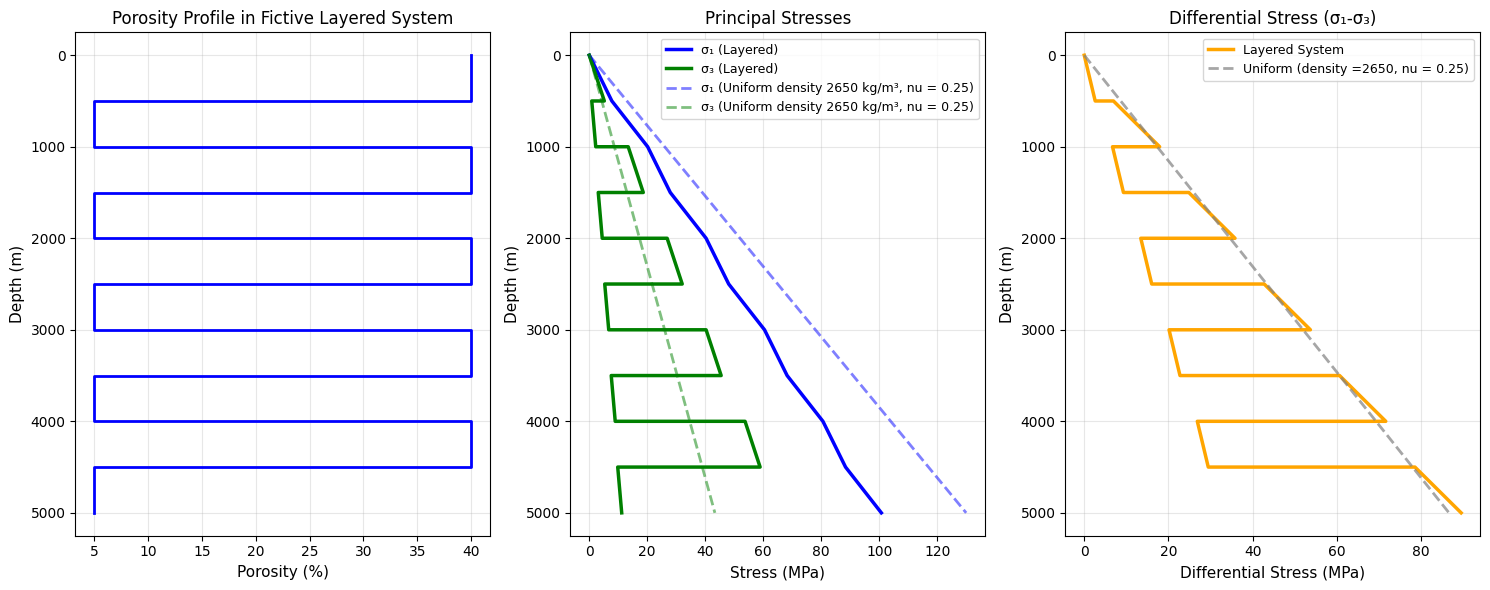

In [5]:
# Task 3c: Layered system with varying properties

import numpy as np
import matplotlib.pyplot as plt

# Define layer properties
rho_grain = 2650
g = 9.81

# Layer types
layer_high = {'phi': 0.40, 'nu': 0.4, 'rho': rho_grain * (1 - 0.40), 'name': 'High Porosity'}
layer_low = {'phi': 0.05, 'nu': 0.1, 'rho': rho_grain * (1 - 0.05), 'name': 'Low Porosity'}

# Create layered system (alternating layers)
def create_layers(layer_thickness, total_depth=5000):
    """Create alternating layers from surface to total_depth"""
    layers = []
    current_depth = 0
    layer_type = layer_high  # Start with high porosity
    
    while current_depth < total_depth:
        next_depth = min(current_depth + layer_thickness, total_depth)
        layers.append({
            'top': current_depth,
            'bottom': next_depth,
            'thickness': next_depth - current_depth,
            **layer_type
        })
        # Alternate layer type
        layer_type = layer_low if layer_type == layer_high else layer_high
        current_depth = next_depth
    
    return layers

# Calculate stress profile through layers
def calculate_layered_stress(layers):
    """Calculate stress considering overburden from all layers above"""
    depths = []
    sigma_1_vals = []
    sigma_3_vals = []
    phi_vals = []
    nu_vals = []
    
    for i, layer in enumerate(layers):
        # Calculate overburden from all layers above
        overburden = sum(l['rho'] * g * l['thickness'] for l in layers[:i])
        
        # Add points at top and bottom of layer
        for z in [layer['top'], layer['bottom']]:
            depths.append(z)
            phi_vals.append(layer['phi'] * 100)
            nu_vals.append(layer['nu'])
            
            # Stress at this depth
            layer_stress = overburden + layer['rho'] * g * (z - layer['top'])
            sigma_1 = layer_stress / 1e6  # Convert to MPa
            sigma_3 = (layer['nu'] / (1 - layer['nu'])) * sigma_1
            
            sigma_1_vals.append(sigma_1)
            sigma_3_vals.append(sigma_3)
    
    return np.array(depths), np.array(sigma_1_vals), np.array(sigma_3_vals), np.array(phi_vals), np.array(nu_vals)

# Create layered system with 500m layer thickness
layer_thickness = 500  # meters
layers = create_layers(layer_thickness)
z, sigma_1, sigma_3, phi, nu = calculate_layered_stress(layers)
diff_stress = sigma_1 - sigma_3

# Calculate uniform rock baseline (constant density and Poisson's ratio)
rho_uniform = 2650  # kg/m³
nu_uniform = 0.25
z_uniform = np.linspace(0, 5000, 100)
sigma_1_uniform = rho_uniform * g * z_uniform / 1e6
sigma_3_uniform = (nu_uniform / (1 - nu_uniform)) * sigma_1_uniform
diff_stress_uniform = sigma_1_uniform - sigma_3_uniform

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Plot 1: Porosity profile
axes[0].plot(phi, z, 'b-', linewidth=2)
axes[0].set_xlabel('Porosity (%)', fontsize=11)
axes[0].set_ylabel('Depth (m)', fontsize=11)
axes[0].set_title('Porosity Profile in Fictive Layered System', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)

# Plot 2: Stress profiles (with uniform comparison)
axes[1].plot(sigma_1, z, 'b-', linewidth=2.5, label='σ₁ (Layered)')
axes[1].plot(sigma_3, z, 'g-', linewidth=2.5, label='σ₃ (Layered)')
axes[1].plot(sigma_1_uniform, z_uniform, 'b--', linewidth=2, alpha=0.5, label='σ₁ (Uniform density 2650 kg/m³, nu = 0.25)')
axes[1].plot(sigma_3_uniform, z_uniform, 'g--', linewidth=2, alpha=0.5, label='σ₃ (Uniform density 2650 kg/m³, nu = 0.25)')
axes[1].set_xlabel('Stress (MPa)', fontsize=11)
axes[1].set_ylabel('Depth (m)', fontsize=11)
axes[1].set_title('Principal Stresses', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9, loc='upper right')

# Plot 3: Differential stress (with uniform comparison)
axes[2].plot(diff_stress, z, 'orange', linewidth=2.5, label='Layered System')
axes[2].plot(diff_stress_uniform, z_uniform, 'gray', linewidth=2, linestyle='--', alpha=0.7, label='Uniform (density =2650, nu = 0.25)')
axes[2].set_xlabel('Differential Stress (MPa)', fontsize=11)
axes[2].set_ylabel('Depth (m)', fontsize=11)
axes[2].set_title('Differential Stress (σ₁-σ₃)', fontsize=12)
axes[2].invert_yaxis()
axes[2].grid(alpha=0.3)
axes[2].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

**Interpretation:** the layered system shows a "staircase" pattern with stress jumps at boundaries due to varying Poisson's ratios - high porosity layers (ν=0.4) produce lower differential stress in average, while low porosity layers (ν=0.1) generate higher differential stress in average. 

If we would play with diffferent layer thickness we would observe this : 


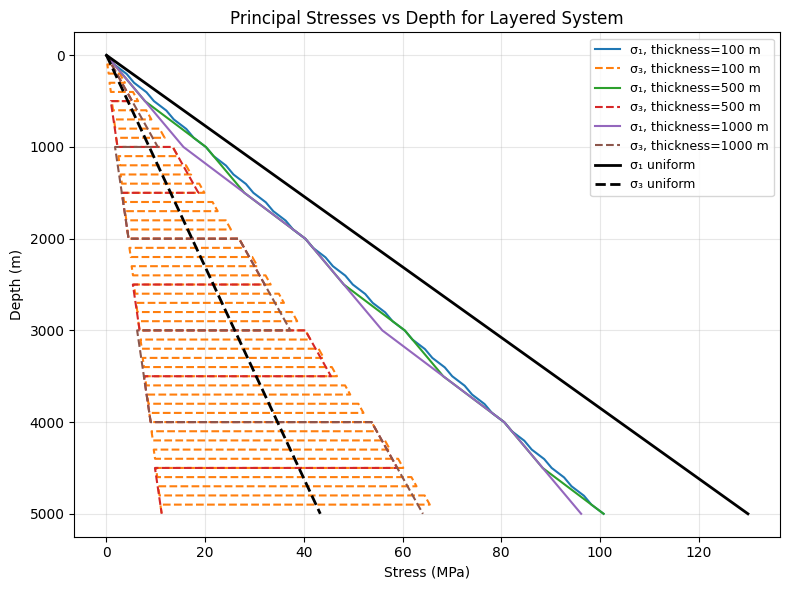

In [6]:

import numpy as np
import matplotlib.pyplot as plt

# Constants
rho_grain = 2650
g = 9.81
total_depth = 5000

# Layer types
layer_high = {'phi': 0.40, 'nu': 0.4, 'rho': rho_grain * (1 - 0.40)}
layer_low  = {'phi': 0.05, 'nu': 0.1, 'rho': rho_grain * (1 - 0.05)}

# Create layered system
def create_layers(layer_thickness, total_depth=5000):
    layers = []
    current_depth = 0
    layer_type = layer_high
    while current_depth < total_depth:
        next_depth = min(current_depth + layer_thickness, total_depth)
        layers.append({'top': current_depth, 'bottom': next_depth, 'thickness': next_depth-current_depth, **layer_type})
        layer_type = layer_low if layer_type==layer_high else layer_high
        current_depth = next_depth
    return layers

# Compute stresses
def calculate_stress(layers, points_per_layer=30):
    depths, sigma_1_vals, sigma_3_vals = [], [], []
    for i, layer in enumerate(layers):
        overburden = sum(l['rho']*g*l['thickness'] for l in layers[:i])
        z_values = np.linspace(layer['top'], layer['bottom'], points_per_layer)
        for z in z_values:
            s1 = (overburden + layer['rho']*g*(z-layer['top'])) / 1e6  # MPa
            s3 = (layer['nu'] / (1 - layer['nu'])) * s1
            depths.append(z)
            sigma_1_vals.append(s1)
            sigma_3_vals.append(s3)
    return np.array(depths), np.array(sigma_1_vals), np.array(sigma_3_vals)

# Layer thicknesses to test
thickness_values = [100, 500, 1000]

plt.figure(figsize=(8,6))
for thickness in thickness_values:
    layers = create_layers(thickness, total_depth)
    z, sigma_1, sigma_3 = calculate_stress(layers)
    plt.plot(sigma_1, z, label=f'σ₁, thickness={thickness} m')
    plt.plot(sigma_3, z, '--', label=f'σ₃, thickness={thickness} m')

# Uniform reference
rho_uniform = 2650
nu_uniform = 0.25
z_uniform = np.linspace(0, total_depth, 500)
sigma_1_uniform = rho_uniform * g * z_uniform / 1e6
sigma_3_uniform = (nu_uniform/(1-nu_uniform)) * sigma_1_uniform
plt.plot(sigma_1_uniform, z_uniform, 'k-', linewidth=2, label='σ₁ uniform')
plt.plot(sigma_3_uniform, z_uniform, 'k--', linewidth=2, label='σ₃ uniform')

plt.gca().invert_yaxis()
plt.xlabel('Stress (MPa)')
plt.ylabel('Depth (m)')
plt.title('Principal Stresses vs Depth for Layered System')
plt.grid(alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

While varying the layer thickness we observe that thin layers increase local stress contrasts and produce strong oscillations in σ₁ and σ₃, whereas thicker layers smooth these variations and make the system behave more like a uniform medium. As a result, differential stress becomes increasingly controlled by bulk density and Poisson’s ratio as layer thickness increases.

---


### *Task 4*

For this we will analyse the three different cases and for each, where the differential stress is maximum because this is where the probabilty of failure is the highest as well. 

<u>For case a) (uniform density) :</u>

To expect if there is any failure and fracturing, we focus on the highest depth (5 km) and where the poisson ration is the lowest (ν= 0.15) because if there is no failure in this case, it will normaly not fail for the other cases. 


The fault as an orientation of 70° to σ₃ and we know that there is 90° between σ₃ and σ1 so there is 20° form σ1 to the fault. 



- Density:  
  $\rho = 2650\ \mathrm{kg/m^3}$

- Vertical stress: 
  $\sigma_1 = \rho g z \approx 130\ \mathrm{MPa}$

  
- $\sigma_3 = \frac{\nu}{1-\nu} \sigma_1$


- Minimum horizontal stress: 
  $$\sigma_3 = \frac{0.15}{0.85} \times 130 \approx 22.9\ \mathrm{MPa}$$

- Formula of the normal stress on the fault plane:  
$$
\sigma_n = \frac{\sigma_1 + \sigma_3}{2} + \frac{\sigma_1 - \sigma_3}{2} \cos(2\alpha)
$$

- Shear stress on the fault plane:  
$$
\tau = \frac{\sigma_1 - \sigma_3}{2} \sin(2\alpha)
$$

- Mohr-Coulomb failure criterion:  
$$
\tau_{\mathrm{fail}} = c + \sigma_n \tan \varphi
$$
---


- Normal stress: 
  $$\sigma_n = 76.5 + 53.5 \cdot 0.766 \approx 117.5\ \mathrm{MPa}$$

- Shear stress:
  $$\tau = 53.5 \cdot 0.643 \approx 34.4\ \mathrm{MPa}$$

---

**Mohr-Coulomb Criterion for Each Rock:** 

we had, 

| Rock Type       | $c$ (MPa) | $\varphi$ (°) | $\tan \varphi$ |
|-----------------|------------|---------------|----------------|
| Pennant         | 28.40      | 43.53         | 0.952          |
| Darley Dale     | 22.00      | 32.62         | 0.639          |
| Red Felser      | 11.98      | 42.23         | 0.904          |




<u>Pennant Sandstone</u>
$$
\tau_{\mathrm{fail}} = 28.40 + 117.5 \times 0.952 \approx 28.40 + 111.9 = 140.3\ \mathrm{MPa}
$$  
  
$\tau = 34.4\ \mathrm{MPa} \ll 140.3\ \mathrm{MPa}$  
➡ Far from failure  



<u>Darley Dale Sandstone</u>
$$
\tau_{\mathrm{fail}} = 22 + 117.5 \times 0.639 \approx 22 + 75.1 = 97.1\ \mathrm{MPa}
$$  
Comparison:  
$\tau = 34.4\ \mathrm{MPa} < 97.1\ \mathrm{MPa}$  
➡ Weakest among the three, but still no failure 



<u>Red Felser</u>
$$
\tau_{\mathrm{fail}} = 11.98 + 117.5 \times 0.904 \approx 11.98 + 106.3 = 118.3\ \mathrm{MPa}
$$  

Comparison:  
$\tau = 34.4\ \mathrm{MPa} < 118.3\ \mathrm{MPa}$  
➡ No failure
  
---

<u>For case b) (Progressive compaction) :</u>

Again, we will calculate for a depth of 5km where  σ1 is the highest, if there is no failure in this case, it will normaly not fail for the other cases.

For progressive compaction (porosity 40% → 0%) at 5 km:  
$\sigma_1(5\ \mathrm{km}) \approx 103.96\ \mathrm{MPa} \approx 104\ \mathrm{MPa}$

We keep:

- $\sigma_1 \approx 104\ \mathrm{MPa}$
- $\nu = 0.25$
- Normal faulting regime:  
  
$$\sigma_3 = \frac{\nu}{1-\nu} \sigma_1 = \frac{0.25}{0.75}\sigma_1 = \frac{1}{3} \sigma_1 
$$  

$$\sigma_3 \approx \frac{104}{3} \approx 34.65\ \mathrm{MPa}$$


- Normal stress:  
$$
\sigma_n = 69.35 + 34.65 \cdot 0.766
$$
$$
\sigma_n  \approx 95.9\ \mathrm{MPa}
$$



- Shear stress:  
$$
\tau = 34.65 \cdot 0.643
$$

(see formula above)
$$
\tau \approx 22.3\ \mathrm{MPa}
$$

<br>
<br>

 
**Mohr–Coulomb Criterion for the Same Rocks:**


<u>Pennant Sandstone</u>
$$
\tau_{\mathrm{fail}} = 28.40 + 95.9 \cdot 0.952 \approx 28.40 + 91.3 = 119.7\ \mathrm{MPa}
$$  
Comparison:  
$\tau = 22.3\ \mathrm{MPa} < 119.7\ \mathrm{MPa}$  
➡ Far from failure

<u>Darley Dale Sandstone</u>
$$
\tau_{\mathrm{fail}} = 22 + 95.9 \cdot 0.639 \approx 22 + 61.3 = 83.3\ \mathrm{MPa}
$$  
Comparison:  
$\tau = 22.3\ \mathrm{MPa} < 83.3\ \mathrm{MPa}$  
➡ No failure

<u>Red Felser</u>
$$
\tau_{\mathrm{fail}} = 11.98 + 95.9 \cdot 0.904 \approx 11.98 + 86.7 = 98.7\ \mathrm{MPa}
$$  
Comparison:  
$\tau = 22.3\ \mathrm{MPa} < 98.7\ \mathrm{MPa}$  
➡ No failure

---

<u>For case c) (layered system with variations in porosity) :</u>

We will again consider the layer at 5km depth and the most critical ones are with low porosity (<5%) because higher density so higher σ1 and low poisson's ratio (0.1)


- From the stress plot:  
  $\sigma_1^{\mathrm{layered}}(5\ \mathrm{km}) \approx 100\ \mathrm{MPa}$


<br>
<br>



$$
\sigma_3 = \frac{\nu_{\mathrm{layer}}}{1-\nu_{\mathrm{layer}}} \sigma_1
$$

With $\nu_{\mathrm{layer}} = 0.1$ and $\sigma_1 = 100\ \mathrm{MPa}$:

$$
\sigma_3 = \frac{0.10}{1-0.10} \cdot 100
= \frac{0.10}{0.90} \cdot 100
$$

$$
\sigma_3 \approx 11.1\ \mathrm{MPa}
$$





<br>
<br>

$$
\sigma_n = 55.6 + 44.4 \times 0.766
$$



$$
\sigma_n \approx  89.7\ \mathrm{MPa}
$$



- Shear Stress on the Plane: 

$$
\tau =
\frac{\sigma_1 - \sigma_3}{2} \sin(40^\circ)
$$


$$
\tau \approx 28.6\ \mathrm{MPa}
$$


<br>
<br> 

**Mohr–Coulomb Criterion for the Same Rocks:**

<br>

<u>Pennant Sandstone</u>

$$
\tau_{\mathrm{fail}} =
28.40 + 89.6 \cdot 0.952
$$

$$
\tau_{\mathrm{fail}} \approx   113.7\ \mathrm{MPa}
$$

Comparison:

$$
\tau = 28.6\ \mathrm{MPa} < 113.7\ \mathrm{MPa}
$$

→ **Far from failure**


<br>

<u>Darley Dale Sandstone</u>

$$
\tau_{\mathrm{fail}} =
22 + 89.6 \cdot 0.639
$$

$$
\tau_{\mathrm{fail}} \approx 79.2\ \mathrm{MPa}
$$

Comparison:

$$
\tau = 28.6\ \mathrm{MPa} < 79.2\ \mathrm{MPa}
$$

→ **No failure**

<br>

<u>Red Felser</u>

$$
\tau_{\mathrm{fail}} =
11.98 + 89.6 \cdot 0.904
$$

$$
\tau_{\mathrm{fail}} \approx  93.0\ \mathrm{MPa}
$$

Comparison:

$$
\tau = 28.6\ \mathrm{MPa} < 93.0\ \mathrm{MPa}
$$

→ **Closer to failure but still no failure**

An illustration of the case is provided in the following plot:





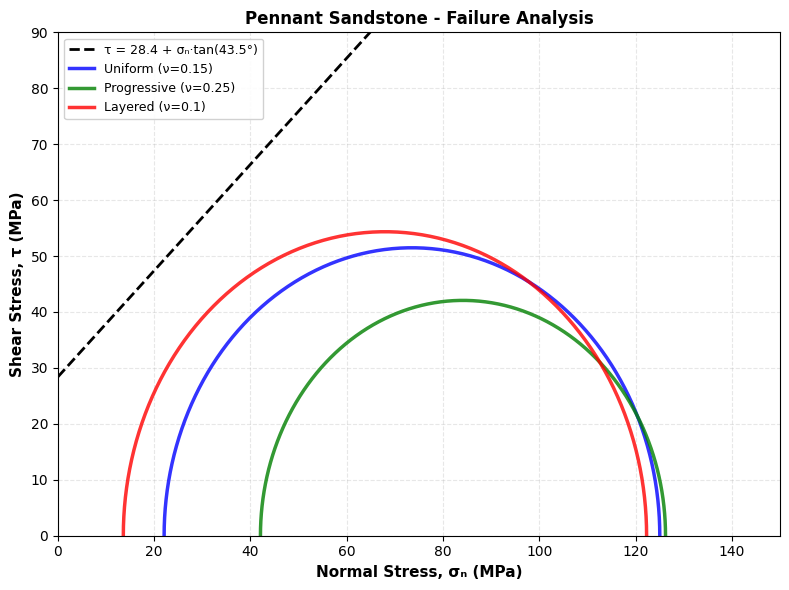

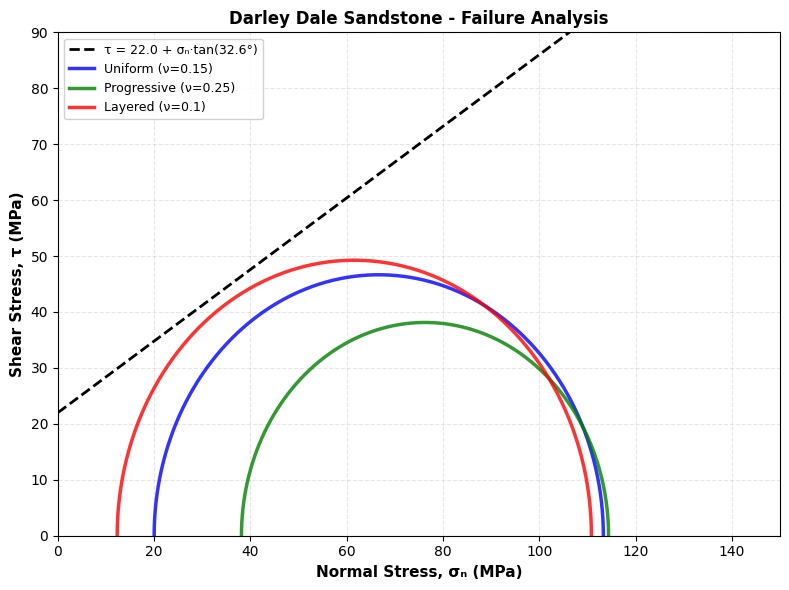

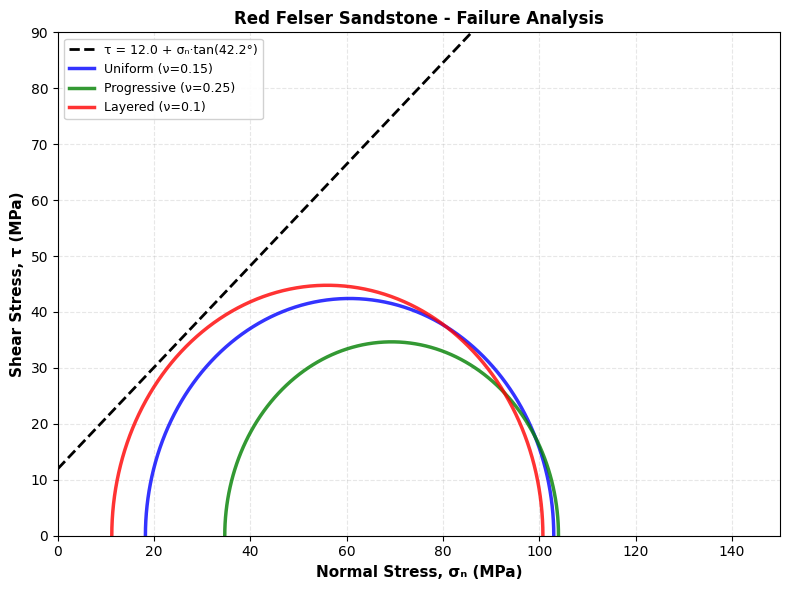

In [7]:
# Task 4: Failure Analysis Setup

import numpy as np
import matplotlib.pyplot as plt

# Rock properties
rock_properties = {
    'Pennant': {'C': 28.40, 'phi': 43.53, 'rho': 2549},
    'Darley Dale': {'C': 22.00, 'phi': 32.62, 'rho': 2310},
    'Red Felser': {'C': 11.98, 'phi': 42.23, 'rho': 2100}
}

# Global parameters
g = 9.81
depth = 5000  # meters

# Define scenarios
scenarios = [
    {'name': 'Uniform (ν=0.15)', 'nu': 0.15, 'rho_type': 'uniform', 'color': 'blue'},
    {'name': 'Progressive (ν=0.25)', 'nu': 0.25, 'rho_type': 'progressive', 'color': 'green'},
    {'name': 'Layered (ν=0.1)', 'nu': 0.1, 'rho_type': 'layered', 'color': 'red'}
]

# Function to calculate sigma_1 based on scenario
def calculate_sigma1(rho_rock, rho_type):
    """Calculate sigma_1 based on rock density and scenario type"""
    if rho_type == 'uniform':
        return rho_rock * g * depth / 1e6
    elif rho_type == 'progressive':
        rho_grain = 2650
        phi_surface = 0.40
        phi_z = phi_surface * (1 - depth / 5000)
        rho_z = rho_grain * (1 - phi_z)
        rho_avg = (rho_grain * (1 - phi_surface) + rho_z) / 2
        rho_avg_scaled = rho_avg * (rho_rock / 2100)
        return rho_avg_scaled * g * depth / 1e6
    else:  # layered
        rho_avg_layer = (1590 + 2518) / 2
        rho_avg_scaled = rho_avg_layer * (rho_rock / 2100)
        return rho_avg_scaled * g * depth / 1e6

# Function to plot failure analysis for a specific rock
def plot_failure_analysis(rock_name):
    """Create failure analysis plot for a specific rock type"""
    # Get rock properties
    C_rock = rock_properties[rock_name]['C']
    phi_deg = rock_properties[rock_name]['phi']
    rho_rock = rock_properties[rock_name]['rho']
    phi_rock = np.radians(phi_deg)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot failure envelope with equation
    sigma_n_envelope = np.linspace(0, 150, 200)
    tau_envelope = C_rock + sigma_n_envelope * np.tan(phi_rock)
    envelope_eq = f'τ = {C_rock:.1f} + σₙ·tan({phi_deg:.1f}°)'
    ax.plot(sigma_n_envelope, tau_envelope, 'k--', linewidth=2, 
            label=f'{envelope_eq}', zorder=10)
    
    # For each scenario, calculate stress and plot Mohr circle
    for scenario in scenarios:
        nu = scenario['nu']
        scenario_color = scenario['color']
        
        # Calculate stress state
        sigma_1 = calculate_sigma1(rho_rock, scenario['rho_type'])
        sigma_3 = (nu / (1 - nu)) * sigma_1
        
        # Plot Mohr circle
        center = (sigma_1 + sigma_3) / 2
        radius = (sigma_1 - sigma_3) / 2
        theta_circle = np.linspace(0, np.pi, 100)
        sigma_n_circle = center + radius * np.cos(theta_circle)
        tau_circle = radius * np.sin(theta_circle)
        ax.plot(sigma_n_circle, tau_circle, linewidth=2.5, color=scenario_color, 
                alpha=0.8, label=scenario['name'])
    
    # Format plot
    ax.set_xlabel('Normal Stress, σₙ (MPa)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Shear Stress, τ (MPa)', fontsize=11, fontweight='bold')
    ax.set_title(f'{rock_name} Sandstone - Failure Analysis', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
    ax.set_xlim(0, 150)
    ax.set_ylim(0, 90)
    
    plt.tight_layout()
    plt.show()
    
    # Pennant Sandstone
plot_failure_analysis('Pennant')

# Darley Dale Sandstone
plot_failure_analysis('Darley Dale')

# Red Felser Sandstone
plot_failure_analysis('Red Felser')

**Interpretation:** Each diagram shows one rock type evaluated under three geological scenarios (uniform, progressive compaction, layered system), with all Mohr circles remaining safely below their respective failure envelopes indicating no failure is expected. The uniform scenario produces the largest differential stress due to low Poisson's ratio (ν=0.15), while the layered system shows the smallest circles due to lower average density. Pennant sandstone demonstrates the highest failure resistance (C=28.4 MPa, φ=43.5°), followed  Darley Dale (C=22.0 MPa, φ=32.6°) and Red Felser (C=11.98 MPa, φ=42.2°).

<br>

---

### *Task 5*



When fluid pressure (Pf) is applied, effective stresses are reduced:

$$
\sigma_1' = \sigma_1 - P_f
$$
 
$$
\sigma_3' = \sigma_3 - P_f
$$

$$P_f = \frac{\sigma_1 - \sigma_3 \cdot N_\varphi - 2C\sqrt{N_\varphi}}{1 - N_\varphi}$$

Where $N_\varphi = \frac{1 + \sin\varphi}{1 - \sin\varphi} = \tan^2\left(45° + \frac{\varphi}{2}\right)$


Illustrations of fluid pressure for failure analysis are showed here:





Pennant Sandstone - Fluid Pressure Analysis
Uniform (ν=0.15)          σ₁(total)=  125.03  σ₃(total)=   22.06  Pf=   28.69
Progressive (ν=0.25)      σ₁(total)=  126.22  σ₃(total)=   42.07  Pf=   52.95
Layered (ν=0.1)           σ₁(total)=  122.29  σ₃(total)=   13.59  Pf=   18.92



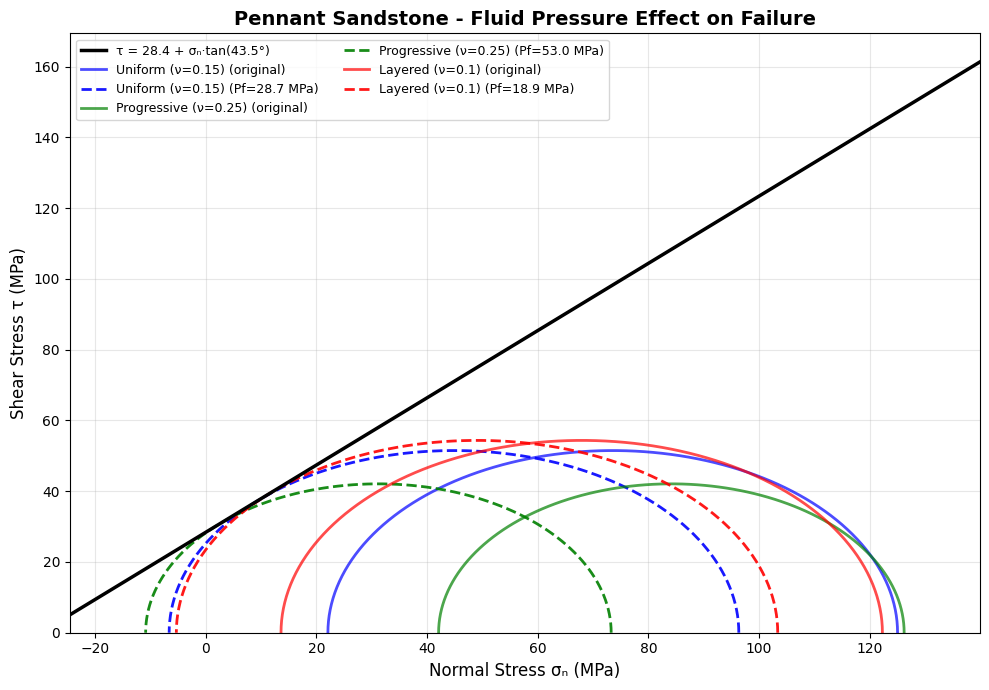

In [8]:
# Task 5: Fluid Pressure for Failure - Setup

import numpy as np
import matplotlib.pyplot as plt

# Function to calculate required fluid pressure for failure
def calculate_failure_pressure(sigma_1, sigma_3, C, phi_deg):
    """Calculate fluid pressure required to cause failure"""
    phi_rad = np.radians(phi_deg)
    
    # Calculate Nφ
    N_phi = (1 + np.sin(phi_rad)) / (1 - np.sin(phi_rad))
    
    # Fluid pressure at failure
    P_f = (sigma_1 - sigma_3 * N_phi - 2 * C * np.sqrt(N_phi)) / (1 - N_phi)
    
    return P_f

# Function to plot fluid pressure analysis with Mohr circles
def plot_fluid_pressure_analysis(rock_name):
    """Plot Mohr circles showing original and failure states with Pf"""
    C = rock_properties[rock_name]['C']
    phi_deg = rock_properties[rock_name]['phi']
    rho_rock = rock_properties[rock_name]['rho']
    phi_rad = np.radians(phi_deg)
    
    # Calculate data for table
    table_data = []
    for scenario in scenarios:
        sigma_1 = calculate_sigma1(rho_rock, scenario['rho_type'])
        nu = scenario['nu']
        sigma_3 = (nu / (1 - nu)) * sigma_1
        P_f = calculate_failure_pressure(sigma_1, sigma_3, C, phi_deg)
        table_data.append({
            'Scenario': scenario['name'],
            'σ₁ (MPa)': f"{sigma_1:.2f}",
            'σ₃ (MPa)': f"{sigma_3:.2f}",
            'Pf for Failure (MPa)': f"{P_f:.2f}"
        })
    
    # Print table
    print(f"\n{'='*78}")
    print(f"{rock_name} Sandstone - Fluid Pressure Analysis")
    print(f"{'='*78}")
    for row in table_data:
        print(f"{row['Scenario']:<25} σ₁(total)={row['σ₁ (MPa)']:>8}  σ₃(total)={row['σ₃ (MPa)']:>8}  Pf={row['Pf for Failure (MPa)']:>8}")
    print(f"{'='*78}\n")
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Plot failure envelope (black) and determine axis limits
    sigma_n_max = 0
    sigma_n_min = float('inf')
    
    # First pass: determine the range of all circles
    for scenario in scenarios:
        sigma_1 = calculate_sigma1(rho_rock, scenario['rho_type'])
        nu = scenario['nu']
        sigma_3 = (nu / (1 - nu)) * sigma_1
        P_f = calculate_failure_pressure(sigma_1, sigma_3, C, phi_deg)
        
        # Track original circle limits
        sigma_n_max = max(sigma_n_max, sigma_1)
        sigma_n_min = min(sigma_n_min, sigma_3)
        
        # Track failure circle limits (shifted left by Pf)
        sigma_3_eff = sigma_3 - P_f
        sigma_n_min = min(sigma_n_min, sigma_3_eff)
    
    # Add margin for better visualization (10% on each side)
    x_margin = (sigma_n_max - sigma_n_min) * 0.1
    sigma_n_plot_min = sigma_n_min - x_margin
    sigma_n_plot_max = sigma_n_max + x_margin
    
    # Plot failure envelope
    sigma_n = np.linspace(sigma_n_plot_min, sigma_n_plot_max, 100)
    tau = C + sigma_n * np.tan(phi_rad)
    envelope_eq = f'τ = {C:.1f} + σₙ·tan({phi_deg:.1f}°)'
    ax.plot(sigma_n, tau, 'k-', linewidth=2.5, label=envelope_eq, zorder=5)
    
    # Plot Mohr circles for each scenario
    for idx, scenario in enumerate(scenarios):
        sigma_1 = calculate_sigma1(rho_rock, scenario['rho_type'])
        nu = scenario['nu']
        sigma_3 = (nu / (1 - nu)) * sigma_1
        
        # Original Mohr circle (without Pf)
        center_orig = (sigma_1 + sigma_3) / 2
        radius_orig = (sigma_1 - sigma_3) / 2
        theta = np.linspace(0, np.pi, 100)
        sigma_n_orig = center_orig + radius_orig * np.cos(theta)
        tau_orig = radius_orig * np.sin(theta)
        ax.plot(sigma_n_orig, tau_orig, color=scenario['color'], linewidth=2, 
                label=f"{scenario['name']} (original)", alpha=0.7)
        
        # Calculate required Pf for failure
        P_f = calculate_failure_pressure(sigma_1, sigma_3, C, phi_deg)
        
        # Mohr circle with Pf applied (at failure)
        sigma_1_eff = sigma_1 - P_f
        sigma_3_eff = sigma_3 - P_f
        center_fail = (sigma_1_eff + sigma_3_eff) / 2
        radius_fail = (sigma_1_eff - sigma_3_eff) / 2
        sigma_n_fail = center_fail + radius_fail * np.cos(theta)
        tau_fail = radius_fail * np.sin(theta)
        ax.plot(sigma_n_fail, tau_fail, color=scenario['color'], linewidth=2, 
                linestyle='--', label=f"{scenario['name']} (Pf={P_f:.1f} MPa)", alpha=0.9)
    
    ax.set_xlabel('Normal Stress σₙ (MPa)', fontsize=12)
    ax.set_ylabel('Shear Stress τ (MPa)', fontsize=12)
    ax.set_title(f'{rock_name} Sandstone - Fluid Pressure Effect on Failure', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(sigma_n_plot_min, sigma_n_plot_max)
    ax.set_ylim(0, None)
    plt.tight_layout()
    plt.show()

# Note: Uses rock_properties, scenarios, and calculate_sigma1 from Task 4 setup
    

    # Pennant Sandstone
plot_fluid_pressure_analysis('Pennant')




---


Darley Dale Sandstone - Fluid Pressure Analysis
Uniform (ν=0.15)          σ₁(total)=  113.31  σ₃(total)=   20.00  Pf=   14.48
Progressive (ν=0.25)      σ₁(total)=  114.38  σ₃(total)=   38.13  Pf=   39.90
Layered (ν=0.1)           σ₁(total)=  110.82  σ₃(total)=   12.31  Pf=    4.57



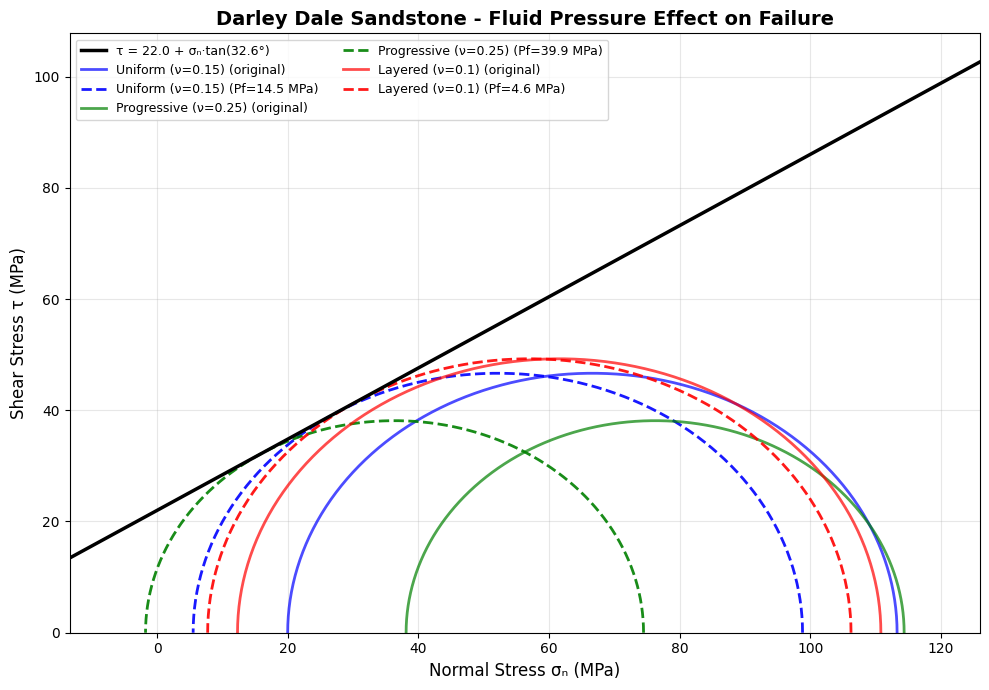

In [9]:
# Darley Dale Sandstone
plot_fluid_pressure_analysis('Darley Dale')

---


Red Felser Sandstone - Fluid Pressure Analysis
Uniform (ν=0.15)          σ₁(total)=  103.00  σ₃(total)=   18.18  Pf=   10.68
Progressive (ν=0.25)      σ₁(total)=  103.99  σ₃(total)=   34.66  Pf=   30.95
Layered (ν=0.1)           σ₁(total)=  100.75  σ₃(total)=   11.19  Pf=    2.55



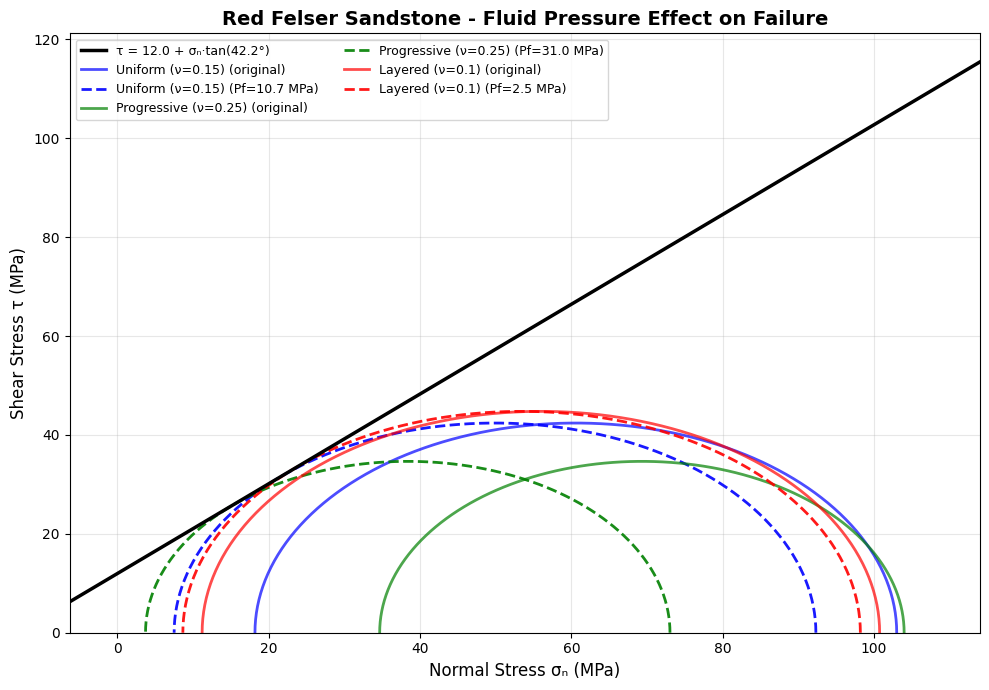

In [10]:
# Red Felser Sandstone
plot_fluid_pressure_analysis('Red Felser')

**Interpretation:** Each diagram visualizes how increased fluid pressure shifts the Mohr circle leftward (reducing effective stresses) until it becomes tangent to the failure envelope, with solid circles showing original stress states and dashed circles showing critical failure conditions. Red Felser requires the lowest fluid pressure to induce failure (7-19 MPa) due to its low cohesion, while Pennant demonstrates highest resistance (40-60 MPa), with the uniform scenario consistently requiring higher Pf values across all rock types. These critical fluid pressures define the upper limit of the mud weight window for safe drilling operations - exceeding these values would cause formation failure.

---

### *Part 2: Linear Elastic Fracture Mechanics*

#### *Task 1*



At 3 km: sigma_v = 77.99 MPa, sigma_h = 26.00 MPa



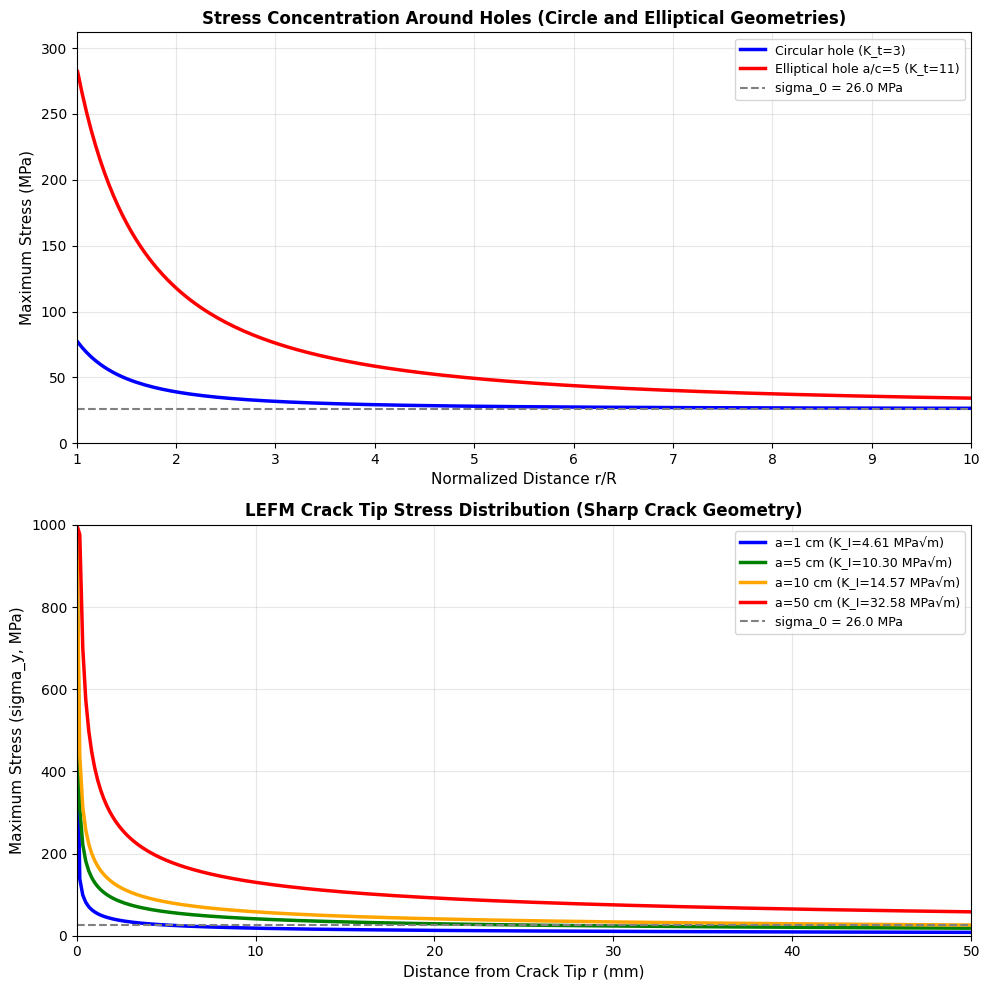

In [11]:
# Part 2, Task 1: Linear Elastic Fracture Mechanics

import numpy as np
import matplotlib.pyplot as plt

# Parameters from Task 3 (3 km depth, uniform scenario)
depth = 3000  # meters
rho = 2650  # kg/m3
g = 9.81  # m/s2
nu = 0.25  # Poisson's ratio

# Calculate stresses at 3 km depth
sigma_v = rho * g * depth / 1e6  # Vertical stress (MPa)
sigma_h = (nu / (1 - nu)) * sigma_v  # Horizontal stress (MPa)

print(f"At 3 km: sigma_v = {sigma_v:.2f} MPa, sigma_h = {sigma_h:.2f} MPa\n")

# Function: Stress concentration factor for elliptical hole
def stress_concentration_factor(a_over_c):
    """Calculate K_t for elliptical hole with aspect ratio a/c"""
    return 1 + 2 * a_over_c

# Function: Stress field near crack tip (LEFM)
def stress_field_crack_tip(K_I, r_array):
    """Calculate stress ahead of crack tip: sigma_yy = K_I / sqrt(2*pi*r)"""
    return K_I / np.sqrt(2 * np.pi * r_array)

# Function: Stress intensity factor
def stress_intensity_factor(sigma_0, a):
    """Calculate K_I for through crack: K_I = sigma_0 * sqrt(pi * a)"""
    return sigma_0 * np.sqrt(np.pi * a)

# Function: Plot stress distribution for different hole geometries
def plot_stress_distribution(sigma_applied):
    """Visualize stress concentration for different geometries"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
    
    # Plot 1: Stress Concentration Around Holes
    r_norm = np.linspace(1.01, 10, 200)  # Normalized distance r/R
    
    # Circular hole (K_t = 3)
    K_t_circle = 3
    sigma_circle = sigma_applied + (K_t_circle * sigma_applied - sigma_applied) * (1.0 / r_norm)**2
    ax1.plot(r_norm, sigma_circle, 'b-', linewidth=2.5, label='Circular hole (K_t=3)')
    
    # Elliptical hole (a/c = 5, K_t = 11)
    K_t_ellipse = stress_concentration_factor(5)
    sigma_ellipse = sigma_applied + (K_t_ellipse * sigma_applied - sigma_applied) * (1.0 / r_norm)**1.5
    ax1.plot(r_norm, sigma_ellipse, 'r-', linewidth=2.5, label='Elliptical hole a/c=5 (K_t=11)')
    
    ax1.axhline(sigma_applied, color='gray', linestyle='--', linewidth=1.5, label=f'sigma_0 = {sigma_applied:.1f} MPa')
    ax1.set_xlabel('Normalized Distance r/R', fontsize=11)
    ax1.set_ylabel('Maximum Stress (MPa)', fontsize=11)
    ax1.set_title('Stress Concentration Around Holes (Circle and Elliptical Geometries)', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9, loc='upper right')
    ax1.grid(alpha=0.3)
    ax1.set_xlim(1, 10)
    ax1.set_ylim(0, max(300, sigma_applied * 12))
    
    # Plot 2: LEFM Crack Tip Stress Field
    r_tip_mm = np.linspace(0.01, 50, 300)  # Distance from crack tip (mm)
    r_tip_m = r_tip_mm / 1000  # Convert to meters
    
    crack_lengths = [0.01, 0.05, 0.1, 0.5]  # meters (1, 5, 10, 50 cm)
    colors = ['blue', 'green', 'orange', 'red']
    
    for a, color in zip(crack_lengths, colors):
        K_I = stress_intensity_factor(sigma_applied, a)
        sigma_tip = stress_field_crack_tip(K_I, r_tip_m)
        sigma_tip = np.minimum(sigma_tip, 1000)  # Truncate unrealistic values
        ax2.plot(r_tip_mm, sigma_tip, color=color, linewidth=2.5,
                label=f'a={a*100:.0f} cm (K_I={K_I:.2f} MPa√m)')
    
    ax2.axhline(sigma_applied, color='gray', linestyle='--', linewidth=1.5,
                label=f'sigma_0 = {sigma_applied:.1f} MPa')
    ax2.set_xlabel('Distance from Crack Tip r (mm)', fontsize=11)
    ax2.set_ylabel('Maximum Stress (sigma_y, MPa)', fontsize=11)
    ax2.set_title('LEFM Crack Tip Stress Distribution (Sharp Crack Geometry)', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9, loc='upper right')
    ax2.grid(alpha=0.3)
    ax2.set_xlim(0, 50)
    ax2.set_ylim(0, 1000)
    
    plt.tight_layout()
    plt.show()

    # Plot: Stress Distribution Analysis
plot_stress_distribution(sigma_h)

**Interpretation:** 

The plots reveal stress amplification differences between fracture geometries at 3 km depth ($σ₀$ = 26 MPa).

The upper plot depicts the stress concentration around holes (where r is actual distance and R is hole radius, and $r/R$ represents normalized distance from hole center). At $r/R = 1$ (at hole edge), the maximum stress occurs here. At $r/R = 2-10$ (moving away from hole), stress decays back to $σ₀$ (far-field stress). Afterall, circular hole indicates moderate stress concentration ($K_t$ = 3, σ_max ≈ 78 MPa at edge), while elliptical holes (a/c=5) shows bigger stress concentration ($K_t$ = 11, σ_max ≈ 286 MPa at tip).

The lower plot depicts sharp crack tip stress field (distance from crack tip):. The $r$ is absolute distance from crack tip in millimeters, that it shows LEFM's 1/√r singularity (stress is highest near crack tip). For this type of crack, a longer crack produces more intense stress fields, for instance the 50 cm crack has ~1000 MPa at r = 0.1 mm from tip, while 1 cm crack has ~300 MPa at r = 0.1 mm from the tip.

---

#### *Task 2*



Based on Task 1 of Part 2, to obtain stress levels at the tip of the fracture that exceed the Mohr-Coulomb failure strength : 
$$
\tau = c + \sigma_n \tan{\phi}
$$

the fracture must have a very sharp geometry. 
Circular holes (at the very left side of the image bellow) only produce moderate stress concentration ($K_t$ = 3) which in general remains bellow the rock failure strength. 
In contrast, elliptical fractures (figure in the middle of the image bellow) with a large $a/c$ ratio increases the stres concentration at the tip and in the case where the minor axis $c$ approaches 0, the geometry becomes sharp (on the very right side of the image). Stresses near the a sharp crack tip increases as 
$$
\sigma \propto \frac{1}{\sqrt{r}}
$$
leading to very large local stresses. Therefore sharp ckracks or very ellongated elliptical fractures are reuqired to generate stresses that exceed the Mohr-Coulomb failure strenght and allow fracture propagation.

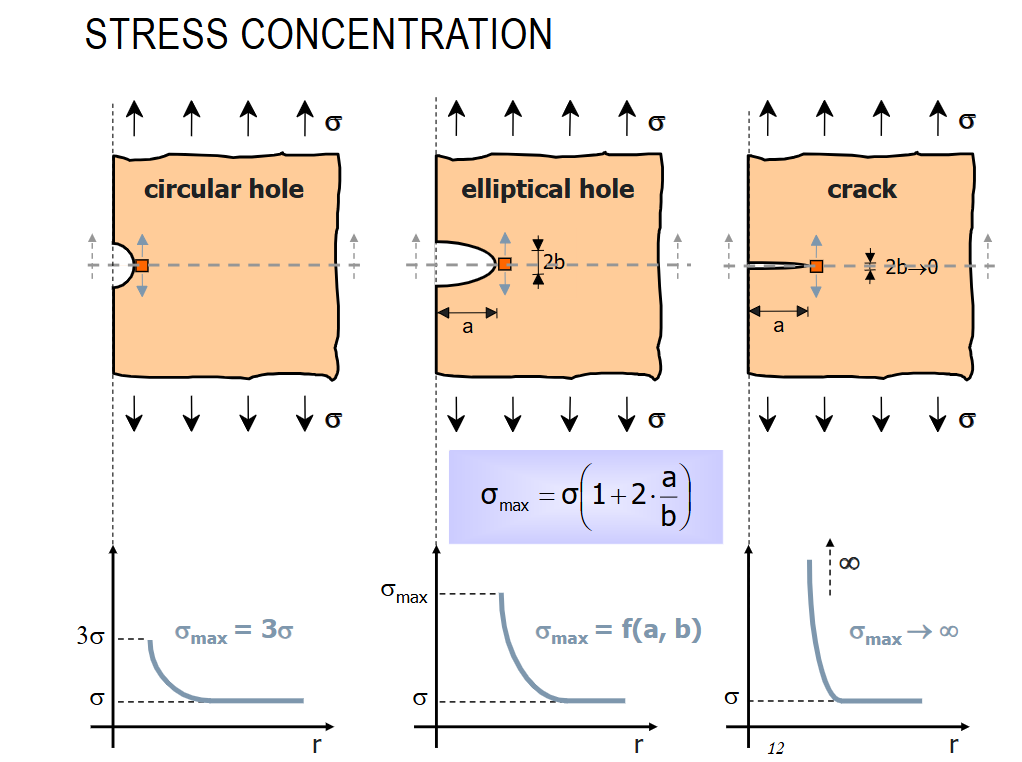

---
